In [ ]:
# Summary of paper
# The paper describes urbanization challenges and how the combination of IoT technology and artificial intelligence allows to develop a fully functional Smart City framework.
# The authors utilize acoustic sensor data collected from upgraded parking terminals along a busy road in Solihull, England. There were two main research objectives.
# Long-term Noise Prediction: The authors compare Deep Learning models against Gradient Boosting to forecast average hourly noise levels.
# Anomaly Detection: Smart city infrastructure is vulnerable to False Data Injection Attacks. By comparing the accurate predictions generated by their CNN-LSTM model against manipulated incoming sensor data, the authors successfully detected injected anomalies using a 5 dB difference threshold.

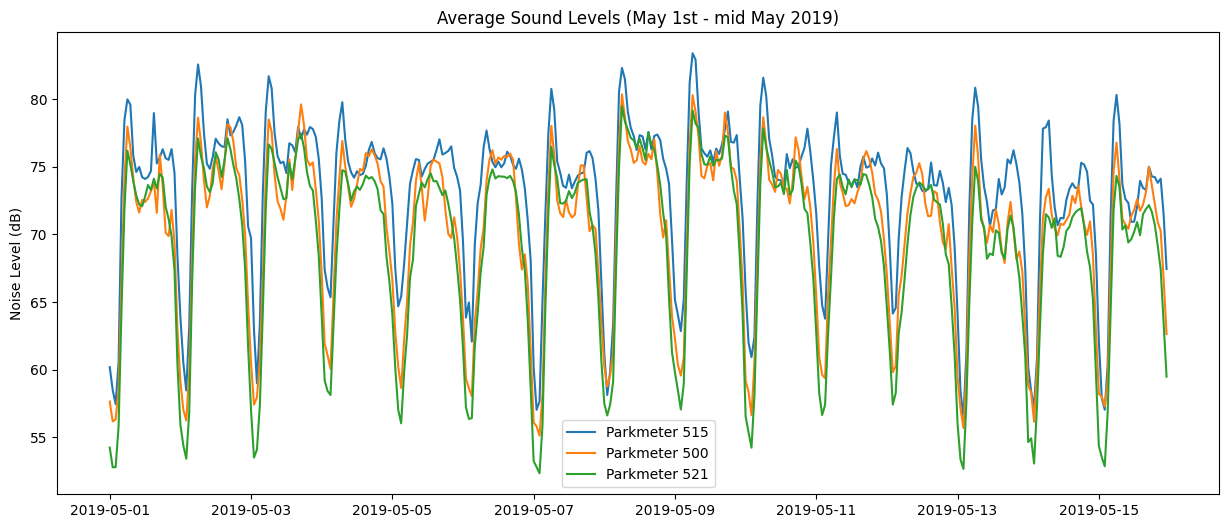

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000607 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6120
[LightGBM] [Info] Number of data points in the train set: 5887, number of used features: 24
[LightGBM] [Info] Start training from score 0.627409
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001495 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6120
[LightGBM] [Info] Number of data points in the train set: 5887, number of used features: 24
[LightGBM] [Info] Start training from score 0.627409
Config 1 Test RMSE: 1.00 dB
Config 2 Test RMSE: 1.00 dB


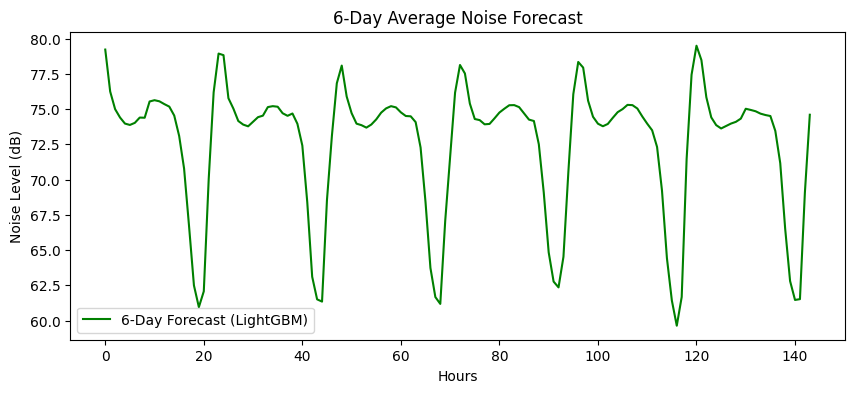

Random Forest Test RMSE: 1.03 dB


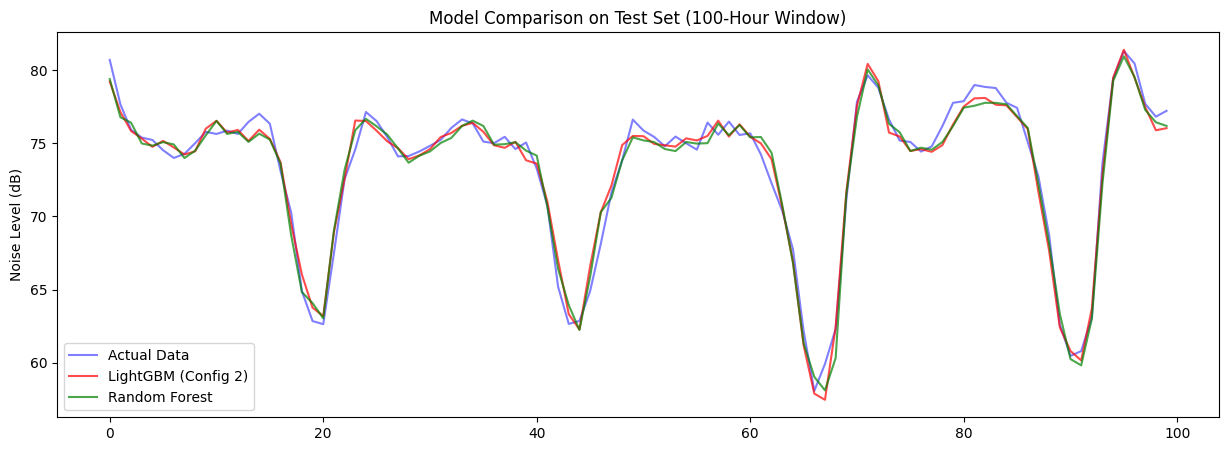

In [2]:
# We are using values given in the paper
# Step 1 - Basic imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# Step 2 - Load data
# Using 'measured_time' instead of 'timestamp' because it has updated data
df_515 = pd.read_csv('DataParkmeter515.csv', parse_dates=['measured_time'], index_col='measured_time', sep=None, engine='python')
df_500 = pd.read_csv('DataParkmeter500.csv', parse_dates=['measured_time'], index_col='measured_time', sep=None, engine='python')
df_521 = pd.read_csv('DataParkmeter521.csv', parse_dates=['measured_time'], index_col='measured_time', sep=None, engine='python')
df_515.sort_index(inplace=True)
df_500.sort_index(inplace=True)
df_521.sort_index(inplace=True)

# Step 3 - Process the 77 histogram columns using Equation (1)
# Equation (1): L(t) = Sum(N_l(t) * (l + 35)) / Sum(N_l(t))
noise_cols = [f'dataNoise{i}' for i in range(77)]

def calculate_average_noise(df):
    # Convert to numeric, turning bad text into 0 to prevent math errors
    df_numeric = df[noise_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
    numerator = 0
    denominator = 0

    for l, col in enumerate(noise_cols):
        numerator += df_numeric[col] * (l + 35)
        denominator += df_numeric[col]

    return numerator / denominator.replace(0, np.nan)

df_515['average_noise'] = calculate_average_noise(df_515)
df_500['average_noise'] = calculate_average_noise(df_500)
df_521['average_noise'] = calculate_average_noise(df_521)

# Step 4 - Resample to 1-hour intervals and filter dates
def resample_and_filter(df):
    df_resampled = df[['average_noise']].resample('1h').mean()
    df_resampled = df_resampled.interpolate(method='linear')

    # Remove timezone formatting so the date filter can apply smoothly
    df_resampled.index = df_resampled.index.tz_localize(None)

    # Filter strictly to May 1, 2019 - Jan 31, 2020
    mask = (df_resampled.index >= '2019-05-01') & (df_resampled.index <= '2020-01-31')
    return df_resampled.loc[mask].dropna()

df_515_hourly = resample_and_filter(df_515)
df_500_hourly = resample_and_filter(df_500)
df_521_hourly = resample_and_filter(df_521)

# Step 5 - Visualize hourly noise trends
plt.figure(figsize=(15, 6))
slice_start, slice_end = '2019-05-01', '2019-05-15'
plt.plot(df_515_hourly[slice_start:slice_end].index, df_515_hourly[slice_start:slice_end]['average_noise'], label='Parkmeter 515')
plt.plot(df_500_hourly[slice_start:slice_end].index, df_500_hourly[slice_start:slice_end]['average_noise'], label='Parkmeter 500')
plt.plot(df_521_hourly[slice_start:slice_end].index, df_521_hourly[slice_start:slice_end]['average_noise'], label='Parkmeter 521')
plt.title('Average Sound Levels (May 1st - mid May 2019)')
plt.ylabel('Noise Level (dB)')
plt.legend()
plt.show()

# Step 6 - Split data and Normalize Parkmeter 515
data_515 = df_515_hourly['average_noise'].values.reshape(-1, 1)

train_size = int(len(data_515) * 0.90)
train_raw, test_raw = data_515[0:train_size], data_515[train_size:]

scaler = MinMaxScaler()
train_data = scaler.fit_transform(train_raw)
test_data = scaler.transform(test_raw)

# Step 7 - Create LightGBM dataset controlled by a look_back value
def create_dataset(dataset, look_back=24):
    X, Y = [], []
    for i in range(len(dataset) - look_back - 1):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

look_back = 24
X_train, y_train = create_dataset(train_data, look_back)
X_test, y_test = create_dataset(test_data, look_back)

# Step 8 - Train LightGBM according to Config 1
# Config 1: num_leaves=11, learning_rate=0.05, n_estimators=500
lgb_config1 = lgb.LGBMRegressor(num_leaves=11, learning_rate=0.05, n_estimators=500, random_state=42)
lgb_config1.fit(X_train, y_train)
pred_test_1 = lgb_config1.predict(X_test)

# Step 9 - Train LightGBM according to Config 2
# Config 2: num_leaves=11, learning_rate=0.04, n_estimators=1000
lgb_config2 = lgb.LGBMRegressor(num_leaves=11, learning_rate=0.04, n_estimators=1000, random_state=42)
lgb_config2.fit(X_train, y_train)
pred_test_2 = lgb_config2.predict(X_test)

# Step 10 - Calculate LightGBM RMSE
def calculate_inverse_rmse(true_scaled, pred_scaled, scaler_obj):
    true_inv = scaler_obj.inverse_transform(true_scaled.reshape(-1, 1))
    pred_inv = scaler_obj.inverse_transform(pred_scaled.reshape(-1, 1))
    return np.sqrt(mean_squared_error(true_inv, pred_inv))

rmse_test_1 = calculate_inverse_rmse(y_test, pred_test_1, scaler)
rmse_test_2 = calculate_inverse_rmse(y_test, pred_test_2, scaler)

print(f"Config 1 Test RMSE: {rmse_test_1:.2f} dB")
print(f"Config 2 Test RMSE: {rmse_test_2:.2f} dB")

# Step 11 - Apply the best configuration to 6-days forecasting
# We use the test set and iteratively predict the next hour, appending it to our inputs.
current_batch = X_test[0].copy()
forecast_scaled = []

for i in range(144):
    current_pred = lgb_config2.predict(current_batch.reshape(1, -1))[0]
    forecast_scaled.append(current_pred)
    current_batch = np.append(current_batch[1:], current_pred)

forecast_inv = scaler.inverse_transform(np.array(forecast_scaled).reshape(-1, 1))

plt.figure(figsize=(10, 4))
plt.plot(range(144), forecast_inv, color='green', label='6-Day Forecast (LightGBM)')
plt.title('6-Day Average Noise Forecast')
plt.xlabel('Hours')
plt.ylabel('Noise Level (dB)')
plt.legend()
plt.show()

# Step 12 - Investigate alternative ML models and compare them
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rmse_rf = calculate_inverse_rmse(y_test, rf_pred, scaler)
print(f"Random Forest Test RMSE: {rmse_rf:.2f} dB")

# Comparison Plot
plt.figure(figsize=(15, 5))
true_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
lgb_test_inv = scaler.inverse_transform(pred_test_2.reshape(-1, 1))
rf_test_inv = scaler.inverse_transform(rf_pred.reshape(-1, 1))

# Plotting a small window of 100 hours to see the difference clearly
plt.plot(true_test_inv[:100], label='Actual Data', color='blue', alpha=0.5)
plt.plot(lgb_test_inv[:100], label='LightGBM (Config 2)', color='red', alpha=0.7)
plt.plot(rf_test_inv[:100], label='Random Forest', color='green', alpha=0.7)
plt.title('Model Comparison on Test Set (100-Hour Window)')
plt.ylabel('Noise Level (dB)')
plt.legend()
plt.show()